This project aims to analyze the instructor’s performance based on the students’ results, engagement, and feedback. It explores the possibility to define the Instructor Effectiveness Score, engineer the corresponding features from the batch data, and train a model that is capable of predicting effectiveness levels (Low, Medium, High).

The project includes an exploratory data analysis, feature engineering, model training, performance assessment, and analysis of findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

In [4]:
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows.csv")

In [5]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [6]:
df.shape

(2000, 12)

In [7]:
df.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


## Dataset Overview

The dataset contains 2000 course batches.
Each row represents one batch taught by an instructor.

The dataset includes:
- 3 identifier columns
- 9 performance-related metrics

In [11]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

## Missing Value Analysis

The dataset contains no missing values. Therefore, no imputation or data cleaning was required before analysis.

In [17]:
df.duplicated().sum()

np.int64(0)

## Duplicate Value Analysis

No duplicate records were found in the dataset.

In [18]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


## Statistical Summary

The statistical summary provides an overview of all numerical features in the dataset.

### Observations

- The dataset contains 2000 records for all numerical columns.
- The average completion rate is *0.603, ranging from **0.30* to *0.98*.
- The average quiz score is *77.96, with values ranging from **40.39* to *100*.
- The average score improvement is *27.04, with a maximum value of **40*.
- The average dropout rate is *0.394, ranging from **0.02* to *0.70*.
- The average watch time is *0.777*, indicating that learners watch a significant portion of the course on average.

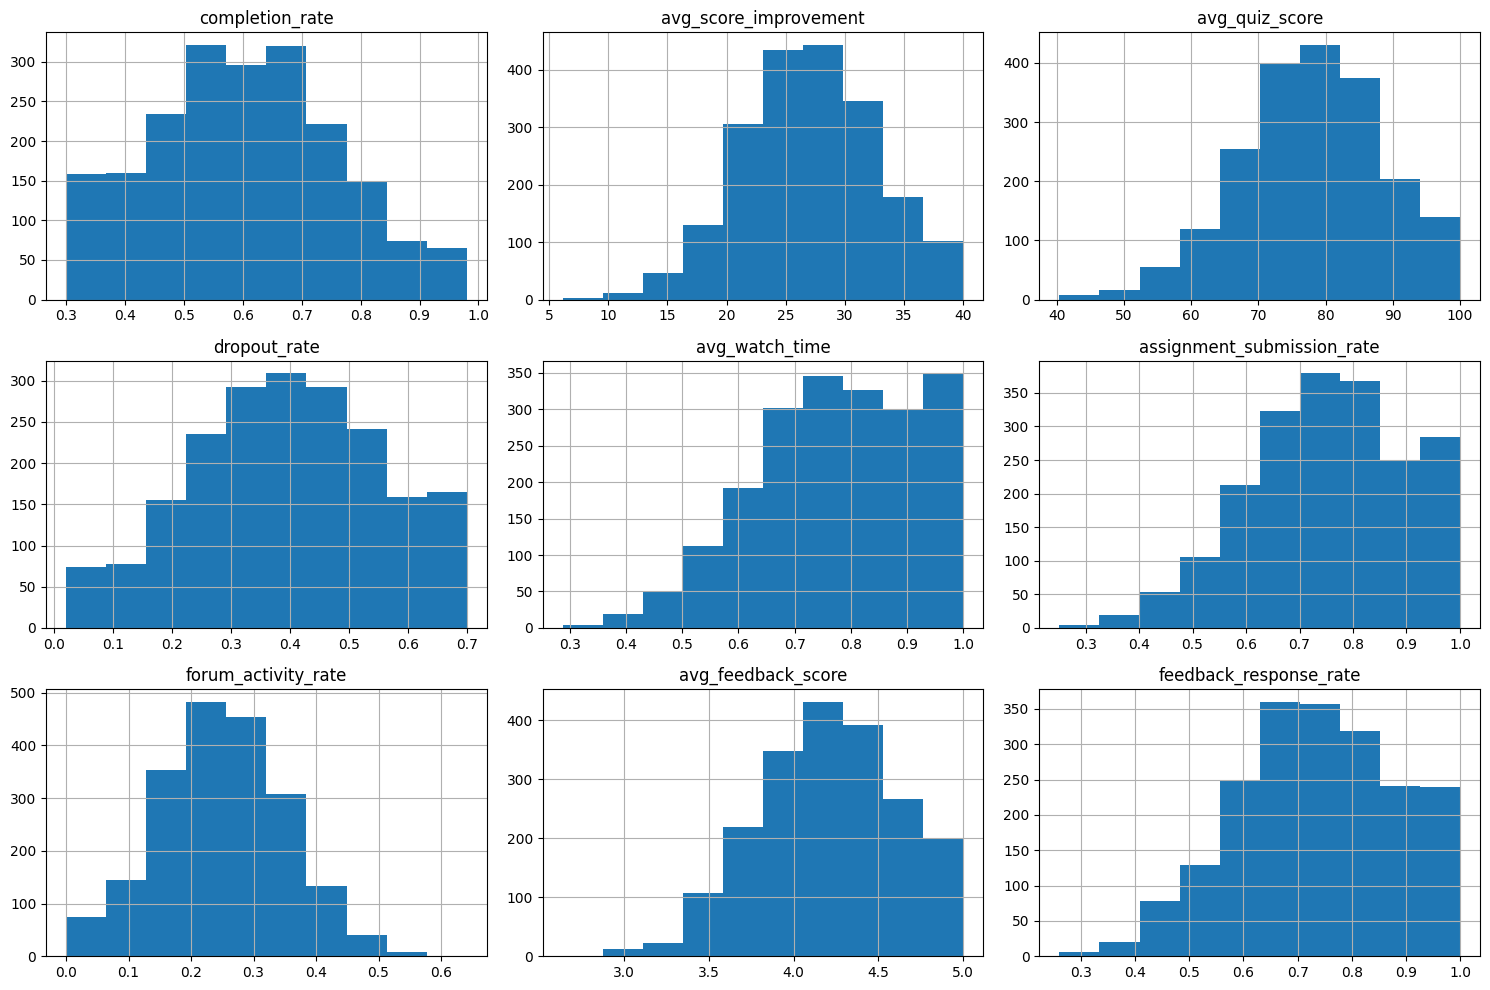

In [ ]:
# df.hist(figsize=(15,10))
# plt.tight_layout()
# plt.show()

## Distribution Analysis
The histogram show the distribution of all numerical features in the dataset.

## Observation
- Completion rate is moderate to high.
- Average score improvement is mostly between 25-30
- Dropout rate is moderate.
- Forum activity rate is low to moderate.
- Quiz score,Watch time, Assignment submission rate, Feedback response rate are generally high.


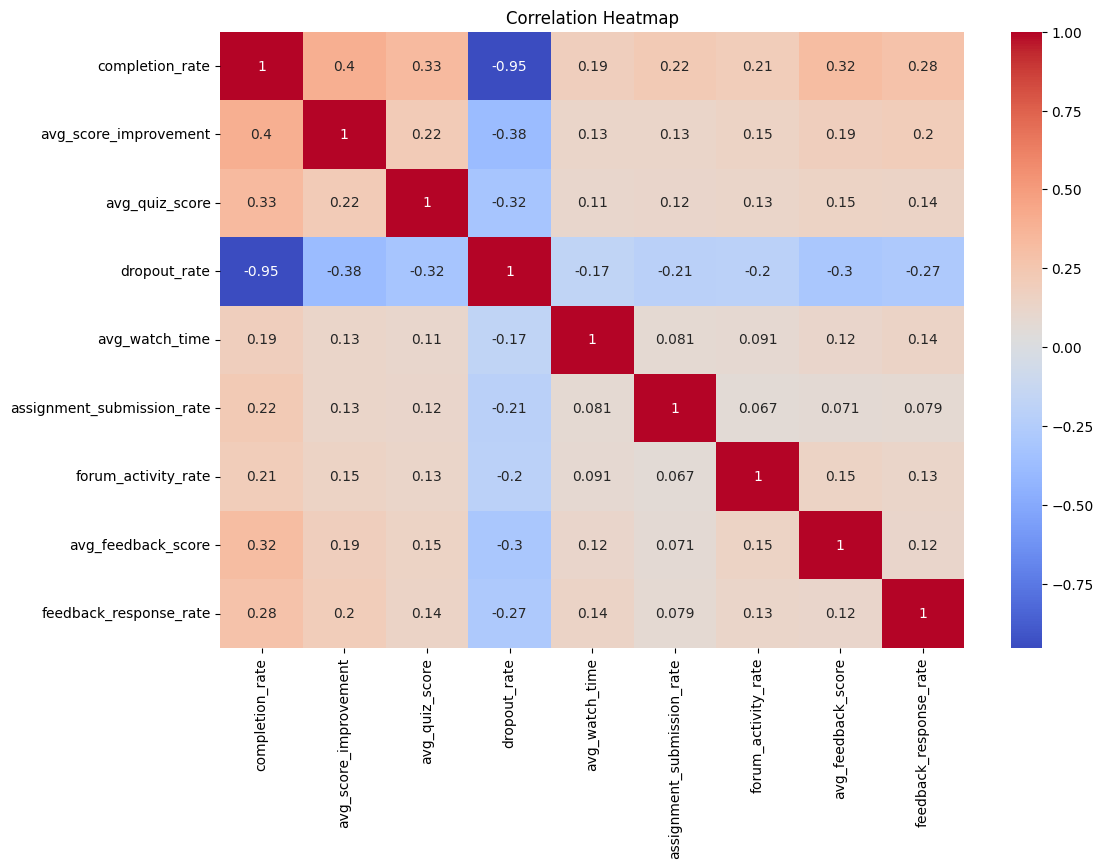

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis
The heatmap shows relationships between numerical features.

## Observation
- Completion rate and dropout rate have a strong negative correlation (-0.95).
- Completion rate has a moderate positive correlation with score improvement and quize score.
- Most other features have weak correlations.

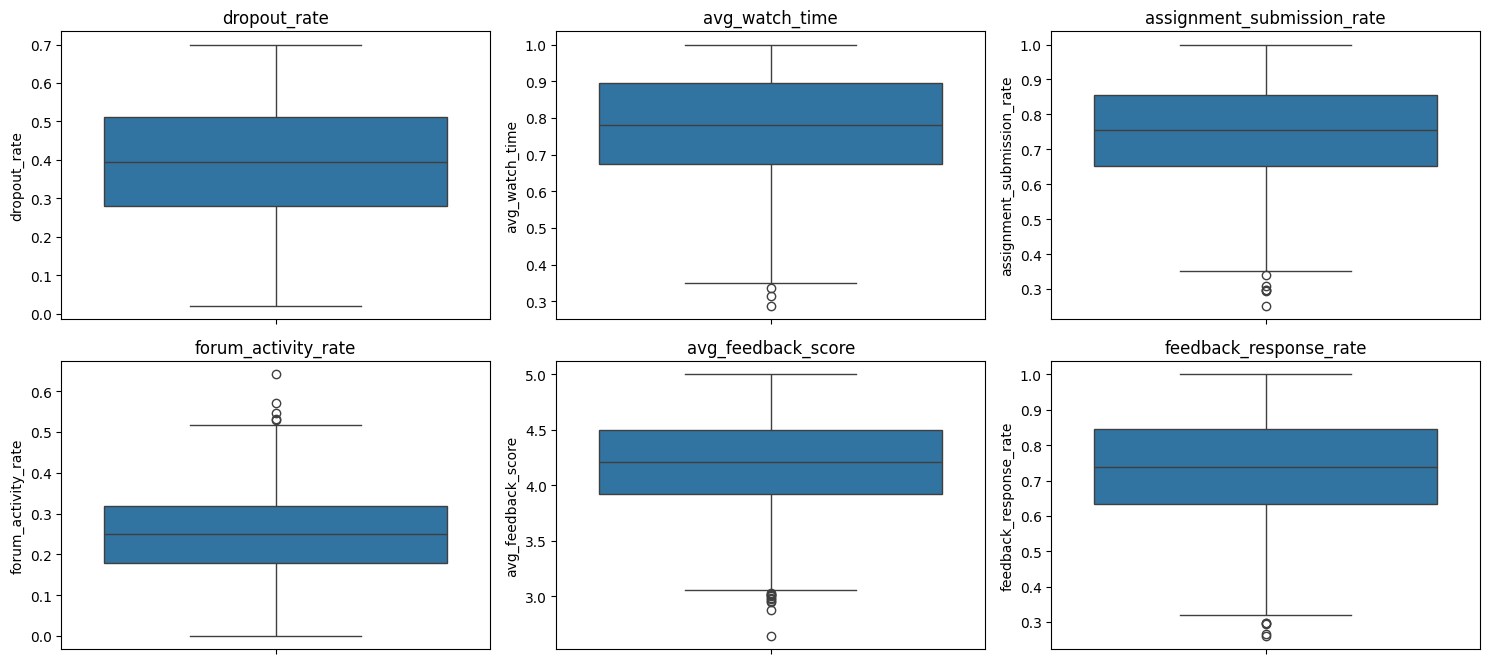

In [23]:
plt.figure(figsize=(15,10))
for i, col in enumerate(df.select_dtypes(include='number').columns[3:]):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Outlier Detection
The boxplots help identify outliers in the numerical features.

## Observation
-Dropout rate has no major outliers.
- Average watch time contains a few lower outliers.
- Assignment submission rate contains a few lower outliers.
- Forum activity rate contains a few upper outliers.
- Average feedback score contains a few lower outliers.
- Feedback response rate contains a few lower outliers.

# Exploratory Data Analysis (EDA) Observations

After analyzing the dataset, the following observations were made:

- The dataset contains 2000 records.
- No missing values were found.
- No duplicate records were detected.
- Completion rates are generally higher than dropout rates.
- Feedback scores are generally high.
- Some numerical features contain mild outliers.
- Most feature pairs show weak to moderate correlations.

# Defining Instructor Effectiveness Score

Since the dataset does not provide a direct measure of instructor effectiveness, an effectiveness score is created using learner outcomes, engagement metrics, and feedback metrics.

The score is designed with the following assumptions:

- Higher course completion indicates better teaching effectiveness.
- Lower dropout rate reflects better learner retention.
- Higher quiz scores and score improvement indicate improved learning outcomes.
- Greater learner engagement (watch time, assignment submission, forum activity) reflects active participation.
- Higher learner feedback scores indicate positive teaching quality.

Each metric is assigned a weight based on its perceived importance. The dropout rate is treated as a negative factor.

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns_to_scale = [
    "completion_rate",
    "dropout_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [25]:
df["effectiveness_score"] = (
0.25 * df["completion_rate"]
+ 0.15 * df["avg_score_improvement"]
+ 0.15 * df["avg_quiz_score"]
+ 0.10 * df["avg_watch_time"]
+ 0.10 * df["assignment_submission_rate"]
+ 0.05 * df["forum_activity_rate"]
+ 0.15 * df["avg_feedback_score"]
+ 0.05 * df["feedback_response_rate"]
- 0.20 * df["dropout_rate"]
)

In [26]:
df[["instructor_id","effectiveness_score"]].head()

,instructor_id,effectiveness_score
0,I_044,0.173603
1,I_119,0.512016
2,I_050,0.214144
3,I_024,0.551910
4,I_001,0.528352


In [27]:
df["effectiveness_score"].describe()

count    2000.000000
mean        0.475142
std         0.156982
min        -0.002130
25%         0.364763
50%         0.478733
75%         0.577512
max         0.927520
Name: effectiveness_score, dtype: float64

## Instructor Effectiveness Score

An Instructor Effectiveness score was created by combining learner outcomes, engagement metrics, and feedback metrics.

### Positive contributors:
The following features contribute positively to the effectiveness score:
- Completion Rate
- Quiz Score
- Score Improvement
- Watch Time
- Assignment Submission Rate
- Forum Activity Rate
- Feedback Score
- Feedback Response Rate

Negative contributor:

- Dropout Rate

All features were normalized using Min-Max Scaling before calculating the weighted score.

In [ ]:
low = df["effectiveness_score"].quantile(0.33)
high = df["effectiveness_score"].quantile(0.66)
print(low)
print(high)

0.40292350842270624
0.5389592925614802


In [29]:
def assign_tier(score):
    if score <= low:
        return "Low"
    elif score <= high:
        return "Medium"
    else:
        return "High"
df["effectiveness_tier"] = df["effectiveness_score"].apply(assign_tier)

In [30]:
df["effectiveness_tier"].value_counts()

effectiveness_tier
High      680
Low       660
Medium    660
Name: count, dtype: int64

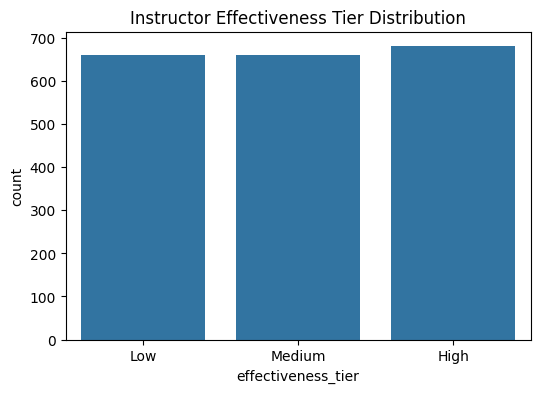

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="effectiveness_tier")
plt.title("Instructor Effectiveness Tier Distribution")
plt.show()

## Effectiveness Tier Classification

The instructor effectiveness score is classified into three categories using percentile-based thresholds.
- Low
- Medium
- High

## Obseravation
- The three categories have a nearly balanced distribution.
- This classification helps compare instructor performance more effectively.

Using quantiles ensures that the classes are balanced and avoids selecting arbitrary cutoff values.

# Aggregate Batch-Level Data to Instructor-Level

Since each instructor may teach multiple batches, the batch-level records are aggregated into instructor-level records.

The **mean** is used for all performance metrics because it provides a representative summary of an instructor's overall teaching performance across multiple batches.

Additionally, the number of batches taught by each instructor is included as a feature to capture teaching experience within the dataset.

In [32]:
instructor_df = df.groupby("instructor_id").agg({

    "completion_rate": "mean",
    "dropout_rate": "mean",
    "avg_score_improvement": "mean",
    "avg_quiz_score": "mean",
    "avg_watch_time": "mean",
    "assignment_submission_rate": "mean",
    "forum_activity_rate": "mean",
    "avg_feedback_score": "mean",
    "feedback_response_rate": "mean",
    "effectiveness_score": "mean",

    # Target column
    "effectiveness_tier": lambda x: x.mode()[0],

    # Number of batches
    "batch_id": "count"

}).rename(columns={
    "batch_id": "num_batches"
}).reset_index()

In [33]:
instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,effectiveness_tier,num_batches
0,I_001,0.358658,0.662637,0.605253,0.646055,0.672327,0.635317,0.375209,0.668547,0.587682,0.424024,Medium,25
1,I_002,0.633639,0.334109,0.709411,0.693645,0.771799,0.698745,0.451731,0.721621,0.708591,0.615360,High,20
2,I_003,0.688892,0.315924,0.703843,0.691192,0.745203,0.705706,0.462047,0.766972,0.746147,0.638840,High,18
3,I_004,0.232836,0.775384,0.495047,0.625592,0.709681,0.677277,0.352917,0.608662,0.623627,0.350050,Low,17
4,I_005,0.823158,0.184902,0.780993,0.762270,0.785317,0.835679,0.520220,0.662095,0.708399,0.723143,High,19


In [34]:
instructor_df.shape

(120, 13)

In [35]:
instructor_df["num_batches"].describe()

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
Name: num_batches, dtype: float64

## Aggregation Summary

Batch-level records were aggregated using the **mean** for numerical features.

The **mode** was used for the effectiveness tier because it represents the most frequent class assigned to an instructor across batches.

The number of batches taught by each instructor was also included as an additional feature.

## Obseravation
- Each number of batches per instructor range from **7** to **31**, with an average of about **17** batches.

In [36]:
X = instructor_df.drop(columns=[
    "instructor_id",
    "effectiveness_tier"
])

y = instructor_df["effectiveness_tier"]

In [37]:
X.head()

,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,num_batches
0,0.358658,0.662637,0.605253,0.646055,0.672327,0.635317,0.375209,0.668547,0.587682,0.424024,25
1,0.633639,0.334109,0.709411,0.693645,0.771799,0.698745,0.451731,0.721621,0.708591,0.615360,20
2,0.688892,0.315924,0.703843,0.691192,0.745203,0.705706,0.462047,0.766972,0.746147,0.638840,18
3,0.232836,0.775384,0.495047,0.625592,0.709681,0.677277,0.352917,0.608662,0.623627,0.350050,17
4,0.823158,0.184902,0.780993,0.762270,0.785317,0.835679,0.520220,0.662095,0.708399,0.723143,19


In [38]:
y.head()

0    Medium
1      High
2      High
3       Low
4      High
Name: effectiveness_tier, dtype: object

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
print(X_train.shape)
print(X_test.shape)

(96, 11)
(24, 11)


# Preparing Data for Machine Learning

The dataset was divided into training and testing sets using an 80:20 split.

Stratified sampling was applied to preserve the class distribution across the effectiveness tiers.

# Model Training

A Random Forest Classifier was selected because it is robust, handles non-linear relationships effectively, and provides feature importance for interpretation.

The model is trained to predict three instructor effectiveness tiers:
- Low
- Medium
- High

In [41]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
y_pred = model.predict(X_test)

In [43]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,Medium,Medium
1,Low,Low
2,Medium,Medium
3,Low,Low
4,High,High
5,Medium,Medium
6,High,High
7,Medium,Medium
8,High,High
9,Low,Low


In [45]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9166666666666666


In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.90      1.00      0.95         9
         Low       1.00      0.88      0.93         8
      Medium       0.86      0.86      0.86         7

    accuracy                           0.92        24
   macro avg       0.92      0.91      0.91        24
weighted avg       0.92      0.92      0.92        24



In [47]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[9 0 0]
 [0 7 1]
 [1 0 6]]


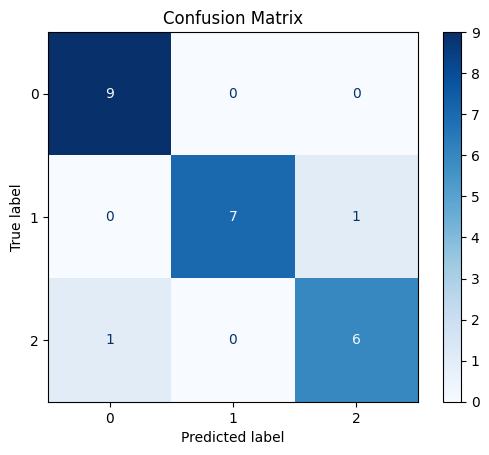

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Model Evaluation

The Random Forest classifier was evaluated using Accuracy, Precision, Recall, F1-score, and the Confusion Matrix.

### Results

- Model Accuracy: **91.67%**
- Most instructors were classified into the correct effectiveness tier.
- Precision, Recall, and F1-scores are above **0.85** for all classes, indicating good classification performance.
- The confusion matrix shows only a few misclassifications, while most predictions are correct.

### Conclusion

The Random Forest model performs well and can effectively classify instructors into Low, Medium, and High effectiveness tiers.

In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

In [50]:
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

In [51]:
feature_importance

,Feature,Importance
9,effectiveness_score,0.246644
0,completion_rate,0.177657
1,dropout_rate,0.139641
7,avg_feedback_score,0.108080
2,avg_score_improvement,0.074013
3,avg_quiz_score,0.071512
8,feedback_response_rate,0.050225
6,forum_activity_rate,0.036124
5,assignment_submission_rate,0.035372
4,avg_watch_time,0.032897


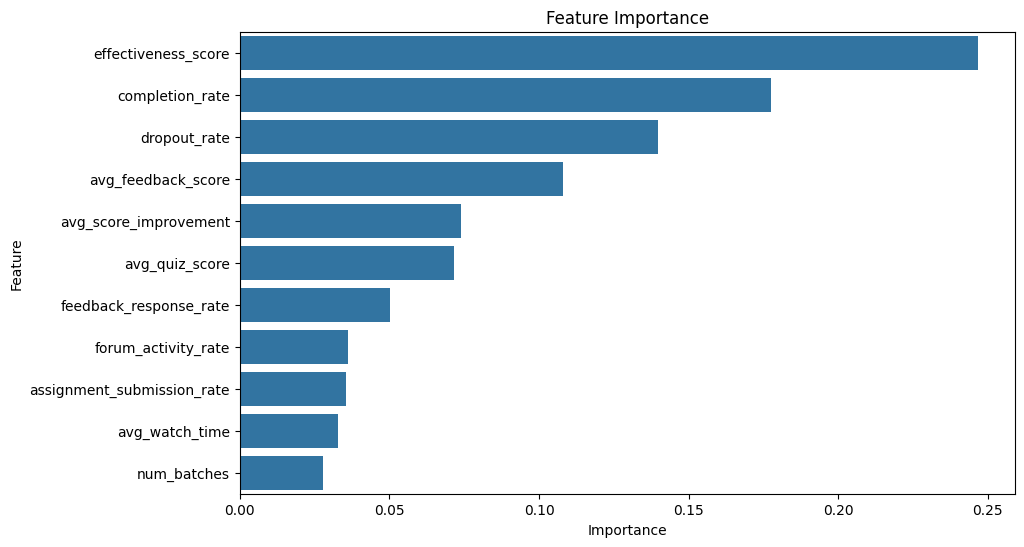

In [52]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()

## Feature Importance Interpretation

The Random Forest model ranks features by their contribution to predicting instructor effectiveness.

The plot shows that **effectiveness_score**, **completion_rate**, **dropout_rate**, and **avg_feedback_score** are the most important features, while the remaining features have a relatively lower impact.

Overall, learner performance, completion, and feedback metrics play the biggest role in the model's predictions.

# Question 1

## Which features most influenced instructor effectiveness, and why?

According to the feature importance analysis from the Random Forest model, the most influential features were completion rate, average quiz score, average score improvement, learner engagement metrics (watch time and assignment submission rate), and average feedback score.

These features directly represent learner success, engagement, and satisfaction. Higher completion rates, better assessment performance, active participation, and positive learner feedback are strong indicators of effective teaching.

# Question 2

## Which variables could be misleading or confounded?

Some variables may not always represent instructor quality accurately.

For example:

- Feedback scores may be influenced by course difficulty rather than teaching quality.
- Completion rates may depend on learner motivation.
- Quiz scores can vary depending on assessment difficulty.
- Forum activity may be influenced by the nature of the course rather than instructor performance.

Therefore, these variables should be interpreted carefully.

# Question 3

## How could this model fail in real-world usage?

The model has several limitations.

- It does not consider course difficulty.
- New instructors with limited teaching history may not have sufficient data.
- Student motivation and prior knowledge are not included.
- Feedback ratings may contain personal bias.
- External factors affecting learner performance are not captured.

As a result, predictions should be interpreted as supportive insights rather than absolute measures of instructor quality.

# Question 4

## What additional data would improve this analysis?

The model could be improved by including additional information such as:

- Instructor teaching experience
- Years of industry experience
- Class attendance records
- Live session participation
- Course difficulty level
- Student demographics
- Student prior knowledge
- Assignment quality scores
- Peer reviews of instructors

These features would provide a more comprehensive evaluation of instructor effectiveness.

# Question 5

## Should this model be used for instructor performance evaluation? Why or why not?

This model should not be used as the sole basis for evaluating instructor performance.

Although it provides valuable insights using learner outcomes, engagement, and feedback, many important factors are not included in the dataset. Human judgment, peer reviews, classroom observations, and contextual information should also be considered.

Therefore, the model should be used as a decision-support tool rather than a replacement for human evaluation.

# Conclusion

This project analyzed instructor effectiveness using learner outcomes, engagement metrics, and learner feedback.

An Instructor Effectiveness Score was designed by combining multiple performance indicators with justified weights. Batch-level records were aggregated to instructor-level records, and a Random Forest Classifier was trained to predict instructor effectiveness tiers.

The model demonstrated the ability to classify instructors based on the available data, while feature importance analysis highlighted the key factors influencing predictions.

Although the model provides useful insights, it has limitations due to the absence of contextual factors such as course difficulty, instructor experience, and learner background. Therefore, the model should be used to support decision-making rather than as the sole measure of instructor performance.

Future improvements could include additional instructor and learner-related features, experimenting with different machine learning algorithms, and validating the model using real-world educational data.